In [55]:
import pandas as pd
import numpy as np
import pingouin as pg
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [56]:
# System and OS related tasks
import sys
import os

# Add the project root to Python path
project_root = os.path.abspath('..')
sys.path.insert(0, project_root)

# path to directories
raw_dir = '../data/raw'
processed_dir = '../data/processed'

# 1.0 Introduction: Hypothesis Testings 

This notebook will cover the following hypothesis testings:
* Hypothesis 1: Climate impact on tea yield
* Hypothesis 2: GDP impact on tea yield
* Hypothesis 3: Crop dominance vs climate

> As this will be a long notebook, it will be sectioned as follows:
>
> * X.0 Hypothesis No 1: 
>
>   * X.1 Preparing the Data
>
>   * X.2 Data Exploration (EDA)
>        * various data visualisation plots 
>
>   * X.3 Statistical Test
>     * t-test output with p-value or chi-square test
>
>   * X.4 Result Visualisation & Conclusion
>     * various data visualisation plots 
>     * Clear statement of what the visualisation and statistical tests mean together
>

# 2.0 Hypothesis No 1: 🌡️ Climate Impact on 🍵 Tea Yield

> ### Hypothesis No. 1
>
> **H<sub>0</sub>**: Mean tea yield is the same in hot or cool climate countries.
>
> **H<sub>1</sub>**: Mean tea yield differs significantly between hot or cool climate countries.
>

## 2.1 Hypothesis No 1: Preparing the Data

📌 Get the main `🍵 tea` data that has `FAO`, `World Bank's GDP` and `World Bank's Climate` data with the granularity of `country-year` for the `top 15 tea producing countries` over the periods of `2000 to 2024`.

In [57]:
filename = "df_main_tea_gdp_climate.csv"

df_main_tea_gdp_climate = pd.read_csv(
    f"{processed_dir}/{filename}",
    )

df_main_tea_gdp_climate.head(5)

,Country_ISO3,Year,Area_Harvest_Ha,Production_Ton,Yield_Kg_Ha,Crop_Type,Country_Name,GDP_Per_Capita,Temperature,Precipitation,Crop_Dominance
0,ARG,2000,38620.0,323000.0,8363.5,Tea,Argentina,7637.014892,14.45,721.03,tea only
1,ARG,2001,37420.0,309000.0,8257.6,Tea,Argentina,7141.475077,15.08,716.55,tea only
2,ARG,2002,36400.0,306000.0,8406.6,Tea,Argentina,2569.699635,14.84,757.75,tea only
3,ARG,2003,36380.0,304000.0,8356.2,Tea,Argentina,3320.477751,15.23,593.14,tea only
4,ARG,2004,36670.0,306000.0,8344.7,Tea,Argentina,4242.020991,15.24,576.61,tea only


📌 Using the median temperature of these `top 15 tea producing countries` as a criteria for deciding whether a country is in a `Cool` climate or in a `Hot` climate.
* The median temperature is computed based on the 25-year average temperature for each country. 

In [58]:
# calculate the average temperature for each country in a 25-year period
df_avg_temp_by_country = df_main_tea_gdp_climate.groupby("Country_ISO3")["Temperature"].mean().reset_index()
## rename the coloumns
df_avg_temp_by_country.columns = ["Country_ISO3", "Avg_Temp_25yr"]

df_avg_temp_by_country

,Country_ISO3,Avg_Temp_25yr
0,ARG,15.2392
1,BGD,25.7700
2,CHN,7.8312
3,IDN,26.0156
4,IND,25.0488
5,IRN,18.7744
6,JPN,12.0516
7,KEN,25.1412
8,LKA,27.3372
9,MWI,22.7220


📌 Assign hot or cool to each country:

In [59]:
# calculate the median temperature of all the countries 25yr average
tea_country_temp_median = df_avg_temp_by_country["Avg_Temp_25yr"].median()

# make a copy of df_main_tea_gdp_climate
df_main_tea_gdp_climate_zone = df_main_tea_gdp_climate.copy()

df_main_tea_gdp_climate_zone["Climate_Zone"] = df_main_tea_gdp_climate_zone["Temperature"].apply(
    lambda x: "Hot" if x >= tea_country_temp_median else "Cool"
)
print(f"The median temperature in °C is: {tea_country_temp_median}")
print(df_main_tea_gdp_climate_zone["Climate_Zone"].value_counts())
print(df_main_tea_gdp_climate_zone.head(3))

The median temperature in °C is: 22.9248
Climate_Zone
Hot     191
Cool    184
Name: count, dtype: int64
  Country_ISO3  Year  Area_Harvest_Ha  Production_Ton  Yield_Kg_Ha Crop_Type  \
0          ARG  2000          38620.0        323000.0       8363.5       Tea   
1          ARG  2001          37420.0        309000.0       8257.6       Tea   
2          ARG  2002          36400.0        306000.0       8406.6       Tea   

  Country_Name  GDP_Per_Capita  Temperature  Precipitation Crop_Dominance  \
0    Argentina     7637.014892        14.45         721.03       tea only   
1    Argentina     7141.475077        15.08         716.55       tea only   
2    Argentina     2569.699635        14.84         757.75       tea only   

  Climate_Zone  
0         Cool  
1         Cool  
2         Cool  


📌 Double check hot or cool assignment of each country:
* we see that MWI (Malawi) and TZA (Tanbzania) both have "Cool" and "Hot"
* looking at both countries on the map, they both have significant elevation changes.

In [60]:
# check that each country only has 1 climate zone
print(df_main_tea_gdp_climate_zone.groupby("Country_ISO3")["Climate_Zone"].unique())

Country_ISO3
ARG         [Cool]
BGD          [Hot]
CHN         [Cool]
IDN          [Hot]
IND          [Hot]
IRN         [Cool]
JPN         [Cool]
KEN          [Hot]
LKA          [Hot]
MWI    [Cool, Hot]
RWA         [Cool]
TUR         [Cool]
TZA    [Cool, Hot]
UGA          [Hot]
VNM          [Hot]
Name: Climate_Zone, dtype: object


📌 Going into the longitudinal, latitudinal and elevation granularity is beyond the scope of this project.
* As such, 
  * use each country's 25-year average temperature to find the median temperature for all countries in a 25 year period 
  * The country's 25-year average temperature is compared to the median temperature to decide whether a country is in a cool or hot climate.
  * and use that climate zone classification on the df_main_tea_gdp_climate.

In [61]:
# calculate the median temperature of all the countries 25yr average temperatures
tea_country_temp_median = df_avg_temp_by_country["Avg_Temp_25yr"].median()

df_avg_temp_by_country["Climate_Zone"] = df_avg_temp_by_country["Avg_Temp_25yr"].apply(
    lambda x: "Hot" if x >= tea_country_temp_median else "Cool"
)
print(f"The median temperature in °C is: {tea_country_temp_median}")
print(df_avg_temp_by_country.head(15))
print(df_avg_temp_by_country["Climate_Zone"].value_counts())

The median temperature in °C is: 22.9248
   Country_ISO3  Avg_Temp_25yr Climate_Zone
0           ARG        15.2392         Cool
1           BGD        25.7700          Hot
2           CHN         7.8312         Cool
3           IDN        26.0156          Hot
4           IND        25.0488          Hot
5           IRN        18.7744         Cool
6           JPN        12.0516         Cool
7           KEN        25.1412          Hot
8           LKA        27.3372          Hot
9           MWI        22.7220         Cool
10          RWA        19.2808         Cool
11          TUR        12.0696         Cool
12          TZA        22.9248          Hot
13          UGA        23.3640          Hot
14          VNM        24.8792          Hot
Climate_Zone
Hot     8
Cool    7
Name: count, dtype: int64


📌 Now that we have classified a country to a climate_zone. We can apply that to the df_main_tea_gdp_climate as a new dataset df_main_tea_gdp_climate_zone. 

We do a value_count() on the climate_zone column grouped buy country to see that each country is only assign to one climate zone.

In [62]:
# make a copy of df_main_tea_gdp_climate
df_main_tea_gdp_climate_zone = df_main_tea_gdp_climate.copy()

# merge the hot/cool zone column to the df_main_tea_gdp_climate
df_main_tea_gdp_climate_zone = df_main_tea_gdp_climate.merge(
    df_avg_temp_by_country[["Country_ISO3", "Climate_Zone"]]
    , on="Country_ISO3"
    , how="left"
)
df_main_tea_gdp_climate_zone.head(3)
print(df_main_tea_gdp_climate_zone.groupby("Country_ISO3")["Climate_Zone"].unique())

Country_ISO3
ARG    [Cool]
BGD     [Hot]
CHN    [Cool]
IDN     [Hot]
IND     [Hot]
IRN    [Cool]
JPN    [Cool]
KEN     [Hot]
LKA     [Hot]
MWI    [Cool]
RWA    [Cool]
TUR    [Cool]
TZA     [Hot]
UGA     [Hot]
VNM     [Hot]
Name: Climate_Zone, dtype: object


## 2.2 Hypothesis No 1: Data Exploration (EDA)

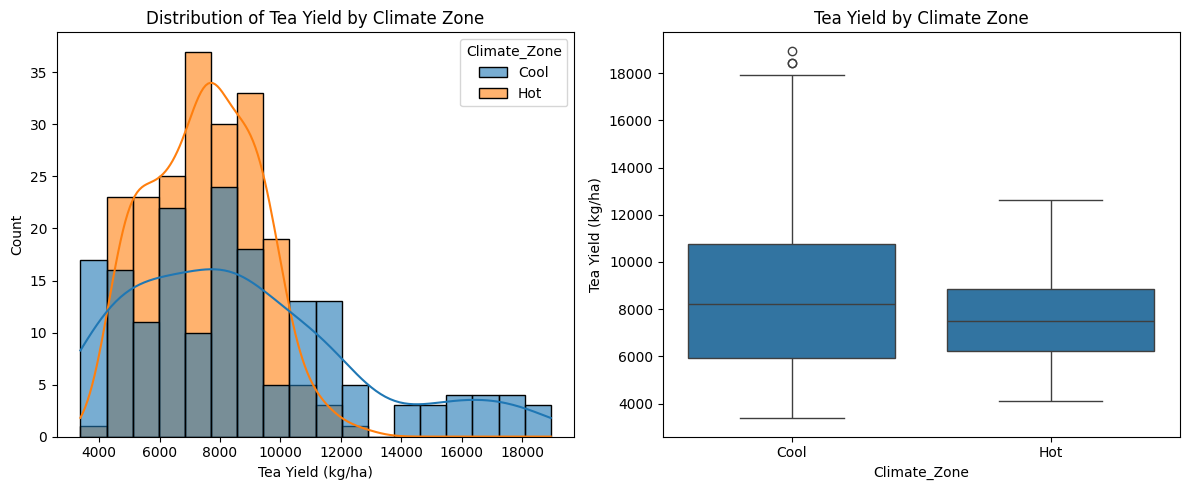

Summary statistics by climate zone:
              count         mean          std     min       25%     50%  \
Climate_Zone                                                              
Cool          175.0  8659.112571  3780.576228  3378.1  5922.450  8226.8   
Hot           200.0  7475.063000  1779.136890  4115.2  6214.825  7498.4   

                    75%      max  
Climate_Zone                      
Cool          10758.100  18948.9  
Hot            8850.425  12620.5  


In [63]:
# Quick EDA: distribution of yield by climate zone
plt.figure(figsize=(12, 5))

# Plot 1: Histogram of yield by climate zone
plt.subplot(1, 2, 1)
sns.histplot(data=df_main_tea_gdp_climate_zone, x='Yield_Kg_Ha', hue='Climate_Zone', kde=True, alpha=0.6)
plt.title('Distribution of Tea Yield by Climate Zone')
plt.xlabel('Tea Yield (kg/ha)')

# Plot 2: Box plot of yield by climate zone
plt.subplot(1, 2, 2)
sns.boxplot(data=df_main_tea_gdp_climate_zone, x='Climate_Zone', y='Yield_Kg_Ha')
plt.title('Tea Yield by Climate Zone')
plt.ylabel('Tea Yield (kg/ha)')

plt.tight_layout()
plt.show()

# Summary statistics by climate zone
print("Summary statistics by climate zone:")
print(df_main_tea_gdp_climate_zone.groupby('Climate_Zone')['Yield_Kg_Ha'].describe())

📌🕵🏻‍♂️ Analysis of the Data Visualizations and Summary Statistics
* the spread of cool and hot observations are around 46% vs 54%. Quite well balanced groups.
* the cool group is slghtly right skewed whilst the hot group is more or less symetrical.
* there appears to be a distinct difference in the means of cool and hot groups which will be tested in our hypothesis later.
* the cool group has a much higher standard deviation than the hot group. 
* the cool group has more outliers and more spread out as compared to the hot group
* the hot group is tighter and has fewer extremes
* the cool group has a higher median than the hot group but the hot group produces more consistently.

> 📌🕵🏻‍♂️ Based on personal experience as trained tea assessor and tea artisan (certified in China), it is expected that any climate with  higher temperature than median temperature of 22.9°C would see a lower yield as the tea plants (in China) as the camellia sinensis tea plant prefers a wider range of temperature variance between day and night which would suggest that the optimal temperature for maximum tea yield would be a lower temperature then then median temperature computed above.

## 2.3 Hypothesis No 1: Statistical Test

We do an independent t-test to see if the difference in yield means between the "cool" group vs the "Hot" group is statistically significant.

Lets do the QQ plots and the normality tests to see if the Yield is normally distributed and if the Cool climate and Hot climates' Yield are normally distributed.

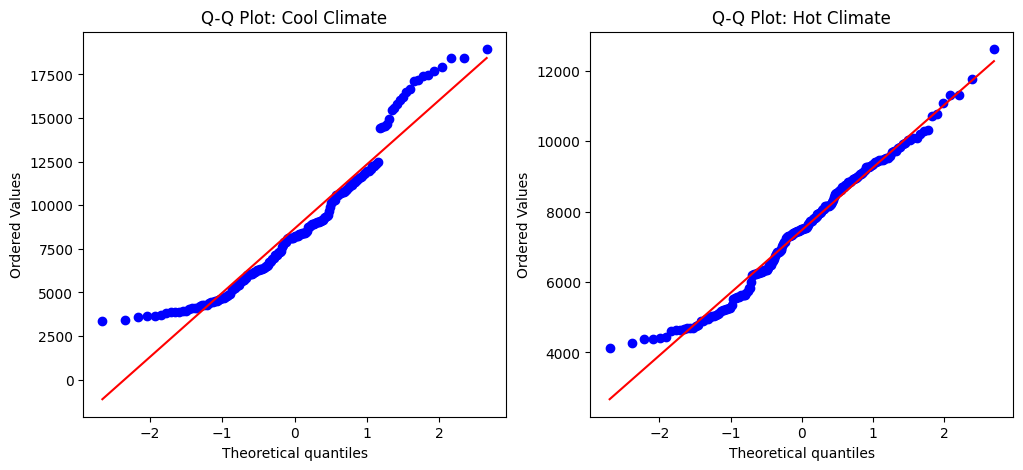

In [64]:
# Split data by climate zone
cool_yield = df_main_tea_gdp_climate_zone[df_main_tea_gdp_climate_zone['Climate_Zone'] == 'Cool']['Yield_Kg_Ha']
hot_yield = df_main_tea_gdp_climate_zone[df_main_tea_gdp_climate_zone['Climate_Zone'] == 'Hot']['Yield_Kg_Ha']

# Q-Q plots to check normality
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
stats.probplot(cool_yield, dist="norm", plot=ax1)
ax1.set_title('Q-Q Plot: Cool Climate')
stats.probplot(hot_yield, dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot: Hot Climate')
plt.show()

📌🕵🏻‍♂️🔍 The QQ plots on the Cool and Hot climate would suggest the the data is not quite normally distributed for the parametric t-test especially for the cool climate Yields. 

📌🕵🏻‍♂️🔍 Indeed, as we look at the normality test both the Yield and the Cool Hot's Yield are not normality distributed as the p-val are significantly less then 0.05.

In [65]:
pg.normality(data=df_main_tea_gdp_climate_zone['Yield_Kg_Ha'], alpha=0.05)

,W,pval,normal
Yield_Kg_Ha,0.91296,6.879638e-14,False


In [66]:
pg.normality(data=df_main_tea_gdp_climate_zone,dv='Yield_Kg_Ha', group='Climate_Zone', alpha=0.05)

,W,pval,normal
Climate_Zone,,,
Cool,0.927466,1.124029e-07,False
Hot,0.980719,7.529145e-03,False


📌🕵🏻‍♂️🔍 As such, we will need to **Mann-Whitney U** test to see if the mean yields of the Cool and Hot climate zones are different.

In [67]:
# Split data by climate zone into 2 data series for the Mann Whitney test
cool_yield = df_main_tea_gdp_climate_zone[df_main_tea_gdp_climate_zone['Climate_Zone'] == 'Cool']['Yield_Kg_Ha']
hot_yield = df_main_tea_gdp_climate_zone[df_main_tea_gdp_climate_zone['Climate_Zone'] == 'Hot']['Yield_Kg_Ha']

pg.mwu(x=cool_yield, y=hot_yield) 

,U_val,alternative,p_val,RBC,CLES
MWU,19738.5,two-sided,0.032591,0.127914,0.563957


## 2.4 Hypothesis No 1: Result Visualisation & Summary Conclusion

📌🕵🏻‍♂️🔍 Look at the box plots 

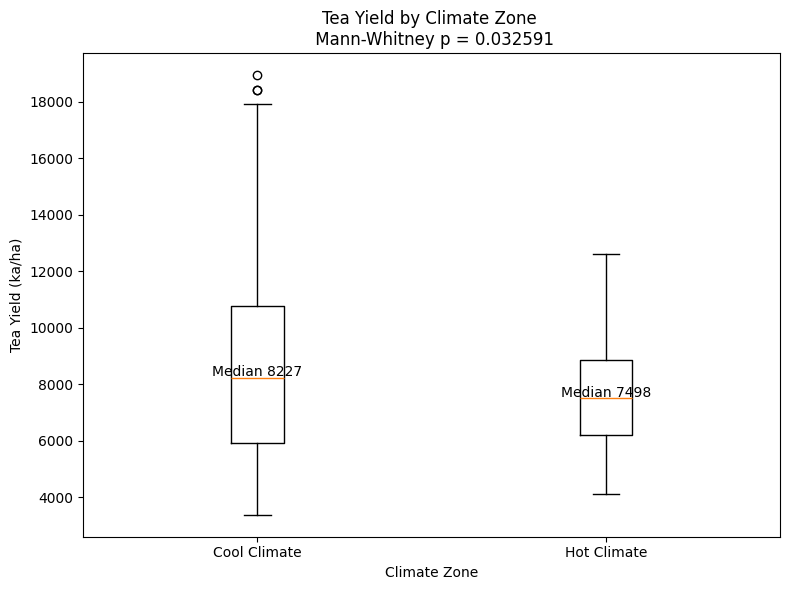

In [68]:
# get the median to shoew on the plot
cool_median = np.median(cool_yield)
hot_median = np.median(hot_yield)

# Create the plot figure so that we can add the titles and labels
plt.figure(figsize=(8, 6))

#do the box plot
box = plt.boxplot(
            [cool_yield, hot_yield]
            , tick_labels=["Cool Climate", "Hot Climate"]
)

# Add the titles and labels and the extra lines to show median
plt.title("Tea Yield by Climate Zone \n Mann-Whitney p = 0.032591")
plt.xlabel("Climate Zone")
plt.ylabel("Tea Yield (ka/ha)")

plt.text(1, cool_median + 50, f"Median {cool_median:.0f}", ha='center')
plt.text(2, hot_median + 50, f"Median {hot_median:.0f}", ha='center')

plt.tight_layout()
plt.show()

In [69]:
print("=================================================")
print("DESCRIPTIVE STATISTICS: Tea Yield by Climate Zone")
print("=================================================")

print("Cool Climate:")
print("-------------")
print(f"Meidan : {cool_yield.median():.0f}")
print(f"Mean   : {cool_yield.mean():.0f}")
print(f"Std Dev: {cool_yield.std():.0f}")
print(f"Min    : {cool_yield.min():.0f}")
print(f"Max    :{cool_yield.max():.0f}")
print(f"IQR    :{cool_yield.quantile(0.75) - cool_yield.quantile(0.25):.0f}")
print("\n")
print("Hot Climate:")
print("-----------")
print(f"Median : {hot_yield.median():.0f}")
print(f"Mean   : {hot_yield.mean():.0f}")
print(f"Std Dev: {hot_yield.std():.0f}")
print(f"Min    : {hot_yield.min():.0f}")
print(f"Max    : {hot_yield.max():.0f}")
print(f"IQR    : {hot_yield.quantile(0.75) - hot_yield.quantile(0.25):.0f}")

DESCRIPTIVE STATISTICS: Tea Yield by Climate Zone
Cool Climate:
-------------
Meidan : 8227
Mean   : 8659
Std Dev: 3781
Min    : 3378
Max    :18949
IQR    :4836


Hot Climate:
-----------
Median : 7498
Mean   : 7475
Std Dev: 1779
Min    : 4115
Max    : 12620
IQR    : 2636


> 📌🕵🏻‍♂️🔍 Based on the results of **Mann-Whitney U** test, since `p = 0.032591` which is < 0.05, we **REJECT** the null hypothesis and conclude that there IS a significant difference in tea yield between hot and cool climate zones.
>
> 📌🕵🏻‍♂️🔍 Now that Null Hypothesis has been reject, when we can also look at the Common Language Effect Size (`CLES = 0.563957`) which represents the probability that a randomly selected score from **Cool climate** is higher than a randomly selected score from **Hot climate**. However, the probabilty of that happening is only slightly more than a 50% chance.
> 

---

# 3.0 Hypothesis No 2: 💵 GDP Impact on 🍵 Tea Yield

> ### Hypothesis No. 2
>
> **H<sub>0</sub>**: `In any given year`, the `mean tea yield` does not differ bettween countries with `above median GDP` and those with `below median GDP`.
>
> **H<sub>1</sub>**: `In any given year`, the `mean tea yield` differs significantly between countries with `above median GDP` and those with `below median GDP`.
>

## 3.1 Hypothesis No 2: Preparing the data

📌 It was highlighted in the notebook 05_Prepare_Data_For_Hypothese (section 1.2) that GDP per capita (in US$) data is not in real terms.

This will allow us to 
* Compare countries in the SAME year.
* Rank countries by GDP within a specific year.
* Use in models with year fixed effects

📌 The nominal GDP per capita is relevant because we are interested in doing a statistical comparing high GDP or low GDP (in any given year) has an impact on tea yields. i.e. whether GDP correlates with yields.
* in this way we are comparing countries **within the same year** 

📌 **Impact on choice of Nominal GDP/capita:**
* Hypotheis Testing: It is fine to use nominal GDP/capita on the hypothesis testing on "Rich countries has more yield in a given year".
* Regression Modelling: We will need to account for time (i.e. year as a dimension) in regression modeling to ensure a "fixed year effect". This require the year variable to be used as a categorical variable.  

In [70]:
df_main_tea_gdp_climate.head(5)

,Country_ISO3,Year,Area_Harvest_Ha,Production_Ton,Yield_Kg_Ha,Crop_Type,Country_Name,GDP_Per_Capita,Temperature,Precipitation,Crop_Dominance
0,ARG,2000,38620.0,323000.0,8363.5,Tea,Argentina,7637.014892,14.45,721.03,tea only
1,ARG,2001,37420.0,309000.0,8257.6,Tea,Argentina,7141.475077,15.08,716.55,tea only
2,ARG,2002,36400.0,306000.0,8406.6,Tea,Argentina,2569.699635,14.84,757.75,tea only
3,ARG,2003,36380.0,304000.0,8356.2,Tea,Argentina,3320.477751,15.23,593.14,tea only
4,ARG,2004,36670.0,306000.0,8344.7,Tea,Argentina,4242.020991,15.24,576.61,tea only


📌 create the column `GDP_Level_By_Year` to group the 15 top tea producing countries GDP into `High GDP` or `Low GDP` in any given year.

In [71]:
df_main_tea_gdp_level = df_main_tea_gdp_climate.copy()

yearly_gdp_medians = df_main_tea_gdp_level.groupby("Year")["GDP_Per_Capita"].median()

yearly_gdp_medians

Year
2000     442.750219
2001     450.357901
2002     469.149929
2003     544.143134
2004     624.258827
2005     710.746760
2006     807.756645
2007    1021.887077
2008    1163.831958
2009    1226.169761
2010    1683.161824
2011    1950.925042
2012    2185.117677
2013    2359.517365
2014    2546.384645
2015    2577.568853
2016    2735.060438
2017    2956.109921
2018    3222.310031
2019    3440.900254
2020    3202.500035
2021    3704.193559
2022    3342.636503
2023    3798.890166
2024    4515.567873
Name: GDP_Per_Capita, dtype: float64

In [72]:
def categorize_year_median_gdp(row):
    if row["GDP_Per_Capita"] >= yearly_gdp_medians[row["Year"]]:
        return "High GDP"
    else:
        return "Low GDP"
# create the new column GDP_Level using the function to compare 
# the GDP_Per_Capita for the Year against pre computed yearly medians    
df_main_tea_gdp_level["GDP_Level"] =  df_main_tea_gdp_level.apply(categorize_year_median_gdp, axis=1)   

df_main_tea_gdp_level["GDP_Level"] .value_counts()

GDP_Level
High GDP    200
Low GDP     175
Name: count, dtype: int64

‼️‼️🐛🏥 It was previously discovered that the year 2024 did not have any GDP_Per_Capital values. This was because the wbgapi that was used to get the GDP data in notebook 03_ETL_WorldBank_GDP wrongly used the year range (2000-2024) when it should be (2000-2025). This has now been fixed and all the subsequent notebook has been re-ran to correct this bug.

## 3.2 Hypothesis No 2: Data Exploration (EDA)

📌 Lets look at the median GDP per Capita of the top 15 tea producers for each of the year

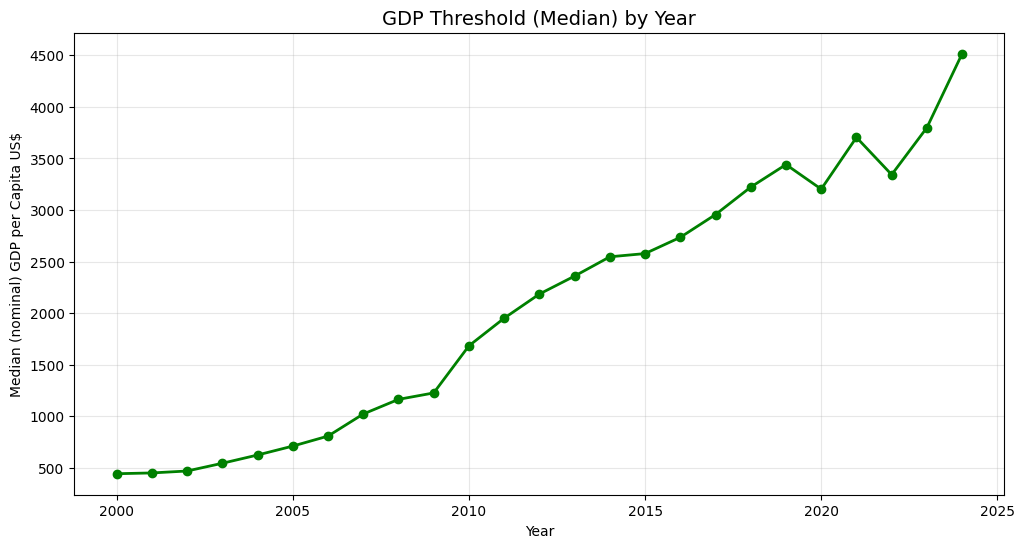

In [73]:
plt.figure(figsize=(12, 6))
# Line graph showing the trend of yearly median GDP of the top 15 tea producing countries
plt.plot(yearly_gdp_medians.index, yearly_gdp_medians.values, 
         marker='o', color='green', linewidth=2)

plt.title('GDP Threshold (Median) by Year', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Median (nominal) GDP per Capita US$')
plt.grid(True, alpha=0.3)
plt.show()


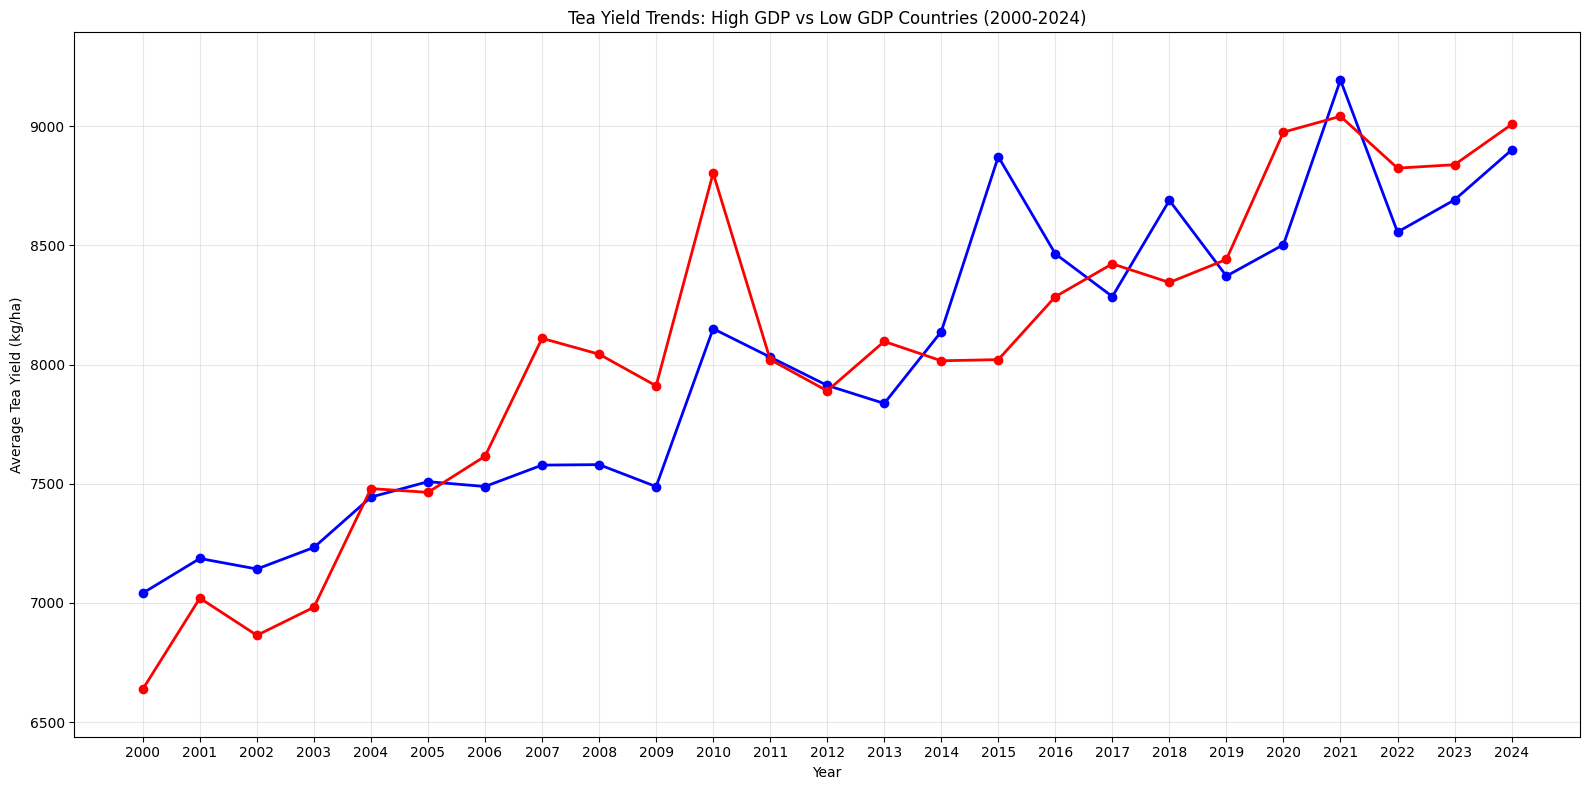

In [137]:
# Calculate yearly averages 
yearly_avg = df_main_tea_gdp_level.groupby(["Year", "GDP_Level"])["Yield_Kg_Ha"].mean().reset_index()

plt.figure(figsize=(16, 8))

# Plot lines for High and Low GDP
for level, color in zip(["High GDP", "Low GDP"], ["blue", "red"]):
    level_data = yearly_avg[yearly_avg['GDP_Level'] == level]
    plt.plot(level_data["Year"], level_data["Yield_Kg_Ha"], 
             marker="o", linewidth=2, color=color, label=level)

# Make y-axis longer by setting limits
y_min = yearly_avg["Yield_Kg_Ha"].min() - 200  # Start 200 below lowest point
y_max = yearly_avg["Yield_Kg_Ha"].max() + 200  # End 200 above highest point
plt.ylim(y_min, y_max)

plt.title("Tea Yield Trends: High GDP vs Low GDP Countries (2000-2024)")
plt.xlabel("Year")
plt.ylabel("Average Tea Yield (kg/ha)")
plt.grid(True, alpha=0.3)

# Put every year on x-axis
all_years = sorted(df_main_tea_gdp_level["Year"].unique())
plt.xticks(ticks=all_years)

plt.tight_layout()
plt.show()


## 3.3 Hypothesis No 2: Statistical Test

> ### Hypothesis No. 2
>
> **H<sub>0</sub>**: `In any given year`, the `mean tea yield` does not differ bettween countries with `above median GDP` and those with `below median GDP`.
>
> **H<sub>1</sub>**: `In any given year`, the `mean tea yield` differs significantly between countries with `above median GDP` and those with `below median GDP`.
>

📌 As we are testing within each year, we can pick a few individual years to look at the data

In [ ]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np

# Pick a year to test
test_year = 2020  
# test_year = 2000 
# test_year = 2010
#  
# Get data for that year
year_data = df_main_tea_gdp_level[df_main_tea_gdp_level["Year"] == test_year]

# Split into High and Low GDP groups
high_gdp = year_data[year_data["GDP_Level"] == "High GDP"]["Yield_Kg_Ha"]
low_gdp = year_data[year_data["GDP_Level"] == "Low GDP"]["Yield_Kg_Ha"]

# Remove any missing values
high_gdp = high_gdp.dropna()
low_gdp = low_gdp.dropna()

print(f"TESTING YEAR: {test_year}")
print("-" * 40)
print(f"High GDP countries: {len(high_gdp)} countries")
print(f"Low GDP countries: {len(low_gdp)} countries")
print("\n Average tea yield:")
print(f"  High GDP: {high_gdp.mean():.1f} kg/ha")
print(f"  Low GDP:  {low_gdp.mean():.1f} kg/ha")
print(f"  Difference: {high_gdp.mean() - low_gdp.mean():.1f} kg/ha")

TESTING YEAR: 2020
----------------------------------------
High GDP countries: 8 countries
Low GDP countries: 7 countries

 Average tea yield:
  High GDP: 8503.0 kg/ha
  Low GDP:  8975.2 kg/ha
  Difference: -472.2 kg/ha


📌 We see which country switches between low and high gdp over the years.

In [111]:
df_main_tea_gdp_level["Country_Name"].value_counts()

Country_Name
Argentina     25
Bangladesh    25
China         25
Indonesia     25
India         25
Iran          25
Japan         25
Kenya         25
Sri Lanka     25
Malawi        25
Rwanda        25
Türkiye       25
Tanzania      25
Uganda        25
Vietnam       25
Name: count, dtype: int64

In [ ]:
# Quick check: see how countries move between groups
country_name = "India"
#country_name = "China"
#country_name = "Uganda"

print(f"Sample: {country_name}'s GDP group over time")
data_results = df_main_tea_gdp_level[df_main_tea_gdp_level["Country_Name"] == country_name][["Year", "GDP_Per_Capita", "GDP_Level"]].head(15)
print(data_results)

Sample: India's GDP group over time
     Year  GDP_Per_Capita GDP_Level
100  2000      442.750219  High GDP
101  2001      450.357901  High GDP
102  2002      469.149929  High GDP
103  2003      544.143134  High GDP
104  2004      624.258827  High GDP
105  2005      710.488080   Low GDP
106  2006      801.668354   Low GDP
107  2007     1021.887077  High GDP
108  2008      992.519585   Low GDP
109  2009     1094.949746   Low GDP
110  2010     1347.519391   Low GDP
111  2011     1445.461275   Low GDP
112  2012     1429.321995   Low GDP
113  2013     1432.843975   Low GDP
114  2014     1553.883961   Low GDP


📌 Some descrriptive stats about the High and Low GDPs.

In [112]:
high_gdp = df_main_tea_gdp_level[df_main_tea_gdp_level["GDP_Level"] == "High GDP"]["Yield_Kg_Ha"].dropna()
low_gdp = df_main_tea_gdp_level[df_main_tea_gdp_level["GDP_Level"] == "Low GDP"]["Yield_Kg_Ha"].dropna()

print(f"High GDP group: {len(high_gdp)} observations")
print(f"Low GDP group: {len(low_gdp)} observations")
print(f"\nHigh GDP summary:\n{high_gdp.describe()}")
print(f"\nLow GDP summary:\n{low_gdp.describe()}")

High GDP group: 200 observations
Low GDP group: 175 observations

High GDP summary:
count      200.000000
mean      8011.392500
std       3501.534648
min       3378.100000
25%       5631.825000
50%       7345.650000
75%       9035.775000
max      18948.900000
Name: Yield_Kg_Ha, dtype: float64

Low GDP summary:
count      175.000000
mean      8046.164571
std       2154.505710
min       4115.200000
25%       6422.800000
50%       8081.200000
75%       9463.500000
max      12620.500000
Name: Yield_Kg_Ha, dtype: float64


📌 QQ plots to look at High and Low GDP distributions

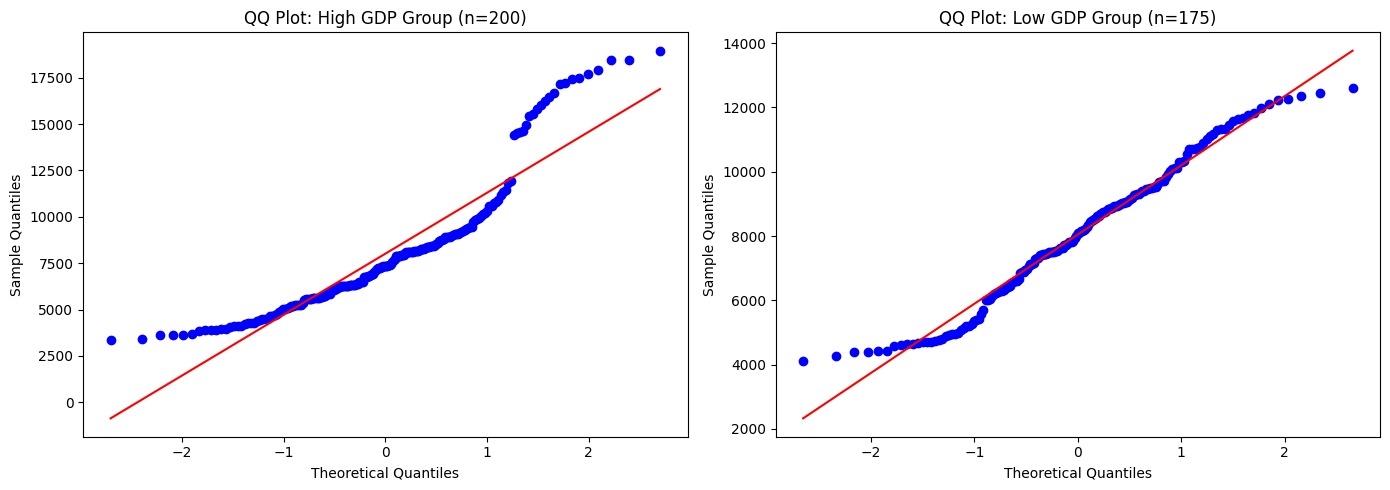

In [113]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# QQ plot for High GDP group
stats.probplot(high_gdp, dist="norm", plot=axes[0])
axes[0].set_title(f"QQ Plot: High GDP Group (n={len(high_gdp)})")
axes[0].set_xlabel("Theoretical Quantiles")
axes[0].set_ylabel("Sample Quantiles")

# QQ plot for Low GDP group
stats.probplot(low_gdp, dist="norm", plot=axes[1])
axes[1].set_title(f"QQ Plot: Low GDP Group (n={len(low_gdp)})")
axes[1].set_xlabel("Theoretical Quantiles")
axes[1].set_ylabel("Sample Quantiles")

plt.tight_layout()
plt.show()

📌 The QQ plots tell us the the high and low GDP's yield distribution is also not normal.

📌 We already seen in the previous hypothesis testing that the Yield_Kg_Ha is not normally distributed

In [117]:
pg.normality(data=df_main_tea_gdp_level['Yield_Kg_Ha'], alpha=0.05)

,W,pval,normal
Yield_Kg_Ha,0.91296,6.879638e-14,False


📌 So are the Low GDP and High GDP's Yields.

In [116]:
pg.normality(data=df_main_tea_gdp_level,dv='Yield_Kg_Ha', group='GDP_Level', alpha=0.05)

,W,pval,normal
GDP_Level,,,
High GDP,0.862905,1.902607e-12,False
Low GDP,0.975212,3.225534e-03,False


📌 As we are comparing within the years, we will need to do the Mann-Whitney U tests for each year.

In [131]:
# Create an empty list to store results
yearly_results = []

# Loop through each year
for year in sorted(df_main_tea_gdp_level["Year"].unique()):
    year_data = df_main_tea_gdp_level[df_main_tea_gdp_level["Year"] == year]
    # divide each year into the high vs low groupings
    high = year_data[year_data["GDP_Level"] == "High GDP"]["Yield_Kg_Ha"].dropna()
    low = year_data[year_data["GDP_Level"] == "Low GDP"]["Yield_Kg_Ha"].dropna()
    
    # Run the test
    result = pg.mwu(high, low, alternative="two-sided")
        
    # Extract values from the mwu tests
    u_stat = result["U_val"].values[0]
    p_val = result["p_val"].values[0]
        
    # APPEND to the results to a yearly ressult list
    yearly_results.append({
            "Year": year,
            "u_statistic": u_stat,
            "p_value": p_val,
            "significant": p_val < 0.05,
            "high_median": high.median(),
            "low_median": low.median(),
            "high_count": len(high),
            "low_count": len(low)
        })
        
    # Optional: print progress
    print(f"For year {year}: p = {p_val:.4f} ➡️ {'SIGNIFICANT' if p_val < 0.05 else 'not significant'}")

# Convert to DataFrame AFTER the loop
yearly_df = pd.DataFrame(yearly_results)

# Show which years were significant
sig_years = yearly_df[yearly_df['significant']]['Year'].tolist()
if sig_years:
    print(f"Significant years: {sig_years}")
else:
    print("No years showed significant differences")

For year 2000: p = 0.8665 ➡️ not significant
For year 2001: p = 0.7789 ➡️ not significant
For year 2002: p = 0.6943 ➡️ not significant
For year 2003: p = 0.6126 ➡️ not significant
For year 2004: p = 0.9551 ➡️ not significant
For year 2005: p = 0.6126 ➡️ not significant
For year 2006: p = 0.6126 ➡️ not significant
For year 2007: p = 0.3969 ➡️ not significant
For year 2008: p = 0.3969 ➡️ not significant
For year 2009: p = 0.2810 ➡️ not significant
For year 2010: p = 0.5358 ➡️ not significant
For year 2011: p = 0.4634 ➡️ not significant
For year 2012: p = 0.6126 ➡️ not significant
For year 2013: p = 0.5358 ➡️ not significant
For year 2014: p = 0.6126 ➡️ not significant
For year 2015: p = 0.8665 ➡️ not significant
For year 2016: p = 0.6943 ➡️ not significant
For year 2017: p = 0.6943 ➡️ not significant
For year 2018: p = 0.8665 ➡️ not significant
For year 2019: p = 0.5358 ➡️ not significant
For year 2020: p = 0.3969 ➡️ not significant
For year 2021: p = 0.6943 ➡️ not significant
For year 2

> 📌🕵🏻‍♂️🔍 Based on the results of **Mann-Whitney U** test, since none of the _**p-val**_ values for each of the year is < 0.05, we `DO NOT REJECT` the null hypothesis and conclude that there `no significant difference` in tea yield between Low GDP and high GDP countries `in any given year`.
> 

## 3.4 Hypothesis No 2: Result Visualisation & Conclusion

> 📌🕵🏻‍♂️🔍 Tea yield appears to be **independent of a country's relative economic wealth** in any given year. This suggests that factors ((such as climate, historical agricultural practices, or long-term investment) other than current GDP may be more important determinants of productivity.
>
> 📌🕵🏻‍♂️🔍 For further work, the real GDP per capital (adjusted for inflation)would allow analysis of wealth–yield relationships across time, rather than only within years.
>
> 📌🕵🏻‍♂️🔍 **Limitation note:** GDP used in this analysis is measured in nominal terms and compared only within years. While this approach is robust to inflation and exchange rate effects, the modest sample size (15 countries per year) limits statistical power, and null findings should be interpreted with appropriate caution. 
>

---

# 4.0 Hypothesis No 3: Crop Dominance vs Climate

> ### Hypothesis No. 3
>
> **H<sub>0</sub>**: ??
>
> **H<sub>1</sub>**: ??
>

## 4.1 Hypothesis No 3: Prepare the Data

## 4.2 Hypothesis No 3: Data Exploration (EDA)

## 4.3 Hypothesis No 3: Statistical Test

## 4.4 Hypothesis No 3: Result Visualisation & Conclusion

---